# Design rule checking

A design that renders is not a design that works. Nothing in Quantum Metal
stops you from routing a resonator straight through a feedline, from putting
a launchpad past the chip edge, or from asking for a 90 um fillet on a 60 um
segment. The picture looks plausible; the chip does not.

`qiskit_metal.validation` is a design rule check (DRC) for that class of
mistake. It reads the built qgeometry tables and reports **findings**:

```python
from qiskit_metal.validation import validate

result = validate(design)
print(result.report())
```

**What the default rules check**

| Rule | Catches | Default | Source |
|---|---|---|---|
| `metal-overlap` | two components' metal overlapping on one layer -- a short | any overlap > 1 um^2 | -- |
| `metal-spacing` | metal close enough that etch residue can bridge it | 2 um | GDSII-to-wafer R8 |
| `cpw-gap` | CPW gap so narrow the interface participation ratio spikes | 3 um | GDSII-to-wafer R1 |
| `chip-bounds` | geometry off the die, silently clipped downstream | -- | -- |
| `short-segment` | a segment too short to host its own fillet arc | fillet radius | -- |
| `qubit-clearance` | a CPW running close enough to a qubit pocket to couple | 3x CPW width | project heuristic |
| `ground-continuity` | the ground plane split into disconnected regions | -- | GDSII-to-wafer R9 |

Severity matters: **ERROR** is geometry that is wrong regardless of intent,
**WARNING** is legal geometry that is probably unintended or spends a physical
budget (loss, stray coupling). Only errors make a result falsy or raise.

These are a starting point, not a foundry sign-off. Every threshold is a
constructor argument -- see *Tuning the rules* below.


In [1]:
# In Colab / Binder, uncomment to install Quantum Metal (lite, no Qt):
# !pip install -q quantum-metal

In [2]:
import qiskit_metal as qm
from qiskit_metal import Dict, designs
from qiskit_metal.qlibrary.qubits.transmon_pocket import TransmonPocket
from qiskit_metal.qlibrary.terminations.launchpad_wb import LaunchpadWirebond
from qiskit_metal.qlibrary.terminations.open_to_ground import OpenToGround
from qiskit_metal.qlibrary.tlines.pathfinder import RoutePathfinder
from qiskit_metal.qlibrary.tlines.straight_path import RouteStraight
from qiskit_metal.validation import validate


def new_design():
    design = designs.DesignPlanar()
    design.overwrite_enabled = True
    design.chips.main.size.size_x = "6mm"
    design.chips.main.size.size_y = "6mm"
    return design


def link(design, name, start, end, ori_start, ori_end, cls=RouteStraight, **options):
    """A CPW between two fresh open terminations -- shorthand for this notebook."""
    OpenToGround(
        design,
        f"{name}_a",
        options=dict(pos_x=start[0], pos_y=start[1], orientation=ori_start),
    )
    OpenToGround(
        design,
        f"{name}_b",
        options=dict(pos_x=end[0], pos_y=end[1], orientation=ori_end),
    )
    return cls(
        design,
        name,
        options=Dict(
            pin_inputs=Dict(
                start_pin=Dict(component=f"{name}_a", pin="open"),
                end_pin=Dict(component=f"{name}_b", pin="open"),
            ),
            **options,
        ),
    )

## A design with one defect per rule

Each block below is a mistake that is easy to make and hard to see. Read them
now, then look at the plot and try to spot them before running the check.

In [3]:
design = new_design()

TransmonPocket(design, "Q1", options=dict(pos_x="0mm", pos_y="0mm"))

# 1. metal-overlap: two CPWs cross. On one layer, that is a short.
link(design, "cross_h", ("-2.6mm", "2mm"), ("-1.2mm", "2mm"), "180", "0")
link(design, "cross_v", ("-1.9mm", "1.4mm"), ("-1.9mm", "2.6mm"), "270", "90")

# 2. metal-spacing: parallel CPWs 1 um apart. Not a short in the CAD, but
#    incomplete etching leaves residue that bridges gaps this narrow.
link(design, "near_a", ("0.6mm", "2.0055mm"), ("2.4mm", "2.0055mm"), "180", "0")
link(design, "near_b", ("0.6mm", "1.9945mm"), ("2.4mm", "1.9945mm"), "180", "0")

# 3. cpw-gap: a 1 um gap concentrates field in the lossy substrate interface.
link(
    design,
    "thin",
    ("-2.6mm", "-2.4mm"),
    ("-0.6mm", "-2.4mm"),
    "180",
    "0",
    trace_gap="1um",
)

# 4. chip-bounds: the launchpad hangs off the die.
LaunchpadWirebond(
    design, "LP", options=dict(pos_x="3.4mm", pos_y="0mm", orientation="180")
)

# 5. short-segment: 100 um legs cannot host a 150 um fillet radius.
link(
    design,
    "kink",
    ("1.2mm", "-2.6mm"),
    ("1.3mm", "-2.5mm"),
    "180",
    "90",
    cls=RoutePathfinder,
    fillet="150um",
)

# 6. qubit-clearance: a CPW skimming Q1's pocket couples to the qubit.
link(design, "hug", ("-1.5mm", "0.35mm"), ("1.5mm", "0.35mm"), "180", "0")

# 7. ground-continuity: a CPW reaching both die edges cuts the ground in two.
link(design, "split", ("-2.994mm", "-1.2mm"), ("2.994mm", "-1.2mm"), "180", "0")

design.rebuild()
design.components.keys()

10:41PM 13s WARNING [check_lengths]: For path table, component=kink, key=trace has short segments that could cause issues with fillet. Values in (1-1)  are index(es) in shapely geometry.


10:41PM 13s WARNING [check_lengths]: For path table, component=kink, key=cut has short segments that could cause issues with fillet. Values in (1-1)  are index(es) in shapely geometry.


10:41PM 13s WARNING [check_lengths]: For path table, component=kink, key=trace has short segments that could cause issues with fillet. Values in (1-1)  are index(es) in shapely geometry.


10:41PM 13s WARNING [check_lengths]: For path table, component=kink, key=cut has short segments that could cause issues with fillet. Values in (1-1)  are index(es) in shapely geometry.


['Q1',
 'cross_h_a',
 'cross_h_b',
 'cross_h',
 'cross_v_a',
 'cross_v_b',
 'cross_v',
 'near_a_a',
 'near_a_b',
 'near_a',
 'near_b_a',
 'near_b_b',
 'near_b',
 'thin_a',
 'thin_b',
 'thin',
 'LP',
 'kink_a',
 'kink_b',
 'kink',
 'hug_a',
 'hug_b',
 'hug',
 'split_a',
 'split_b',
 'split']

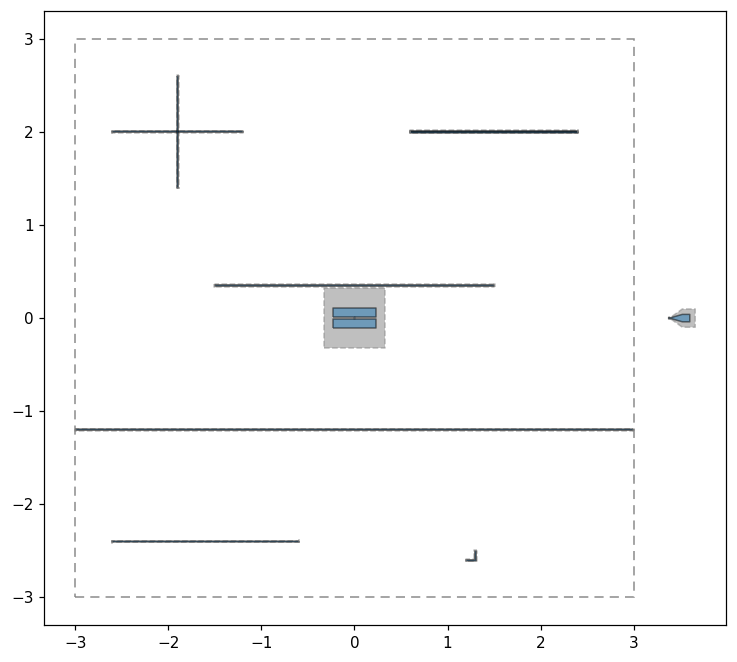

In [4]:
fig = qm.view(design)
qm.show_inline(fig)

The dashed rectangle is the die outline -- `qm.view` draws it so geometry
placed off the chip is visible rather than silently clipped downstream (pass
`chip_outline=False` for the geometry alone). The launchpad on the right is
plainly outside it.

The rest are invisible at this zoom. That is the point -- the eye checks
topology, not micron-scale spacing.

## Run the checks

In [5]:
result = validate(design)
print(result.report())

10 finding(s) from 7 rule(s): 3 error(s), 7 warning(s)
  [error] metal-overlap: cross_h and cross_v overlap by 100 um^2 of metal on layer 1  @ (-1.9000, 2.0000)
  [error] metal-spacing: near_a and near_b are 1.00 um apart (minimum 2.00 um)  @ (2.4000, 2.0000)
  [warning] cpw-gap: thin has a 1.00 um CPW gap (minimum 3.00 um)  @ (-2.6000, -2.4000)
  [error] chip-bounds: LP extends 660.0 um beyond the 'main' chip outline  @ (3.5175, 0.0000)
  [warning] short-segment: kink.trace segment 0 is 100.0 um long but needs 150.0 um for a 150.0 um fillet  @ (1.2500, -2.6000)
  [warning] short-segment: kink.trace segment 1 is 100.0 um long but needs 150.0 um for a 150.0 um fillet  @ (1.3000, -2.5500)
  [warning] short-segment: kink.cut segment 0 is 100.0 um long but needs 150.0 um for a 150.0 um fillet  @ (1.2500, -2.6000)
  [warning] short-segment: kink.cut segment 1 is 100.0 um long but needs 150.0 um for a 150.0 um fillet  @ (1.3000, -2.5500)
  [warning] qubit-clearance: hug passes 14.0 um from Q

## Reading the result

`validate` returns a `ValidationResult`. It is **falsy when there are errors**,
so it drops straight into an `if`. Each `Finding` is a frozen dataclass with
the rule name, severity, message, the components involved, an `(x, y)`
location in millimetres, and the measured `value` against the `limit` it
missed.

In [6]:
print("passes:", bool(result))
print("errors:", len(result.errors), " warnings:", len(result.warnings))

worst = result.errors[0]
print()
print("rule:      ", worst.rule)
print("severity:  ", worst.severity)
print("components:", worst.components)
print("location:  ", worst.location)
print("value/limit:", worst.value, "/", worst.limit)

passes: False
errors: 3  warnings: 7

rule:       metal-overlap
severity:   error
components: ('cross_h', 'cross_v')
location:   (-1.9, 2.0)
value/limit: 9.999999999999574e-05 / 1e-06


In [7]:
# Group by rule to see the shape of the problem rather than a flat list.
from collections import Counter

Counter(f.rule for f in result.findings)

Counter({'short-segment': 4,
         'metal-overlap': 1,
         'metal-spacing': 1,
         'cpw-gap': 1,
         'chip-bounds': 1,
         'qubit-clearance': 1,
         'ground-continuity': 1})

## Fixing them

Each finding names the physics it protects, so the fix is not arbitrary.

1. **`metal-overlap`** -- move `cross_v` clear of `cross_h`. If the crossing is
   deliberate, it needs an airbridge: those sit on their own layer and the rule
   is layer-aware, so a bridged crossing does not report.
2. **`metal-spacing`** -- open the gap to 200 um. The 2 um default comes from
   published superconducting-chip rule sets; your foundry sets the real number.
3. **`cpw-gap`** -- back to the standard 6 um. Narrow gaps push field into the
   substrate-metal interface, where two-level-system loss lives.
4. **`chip-bounds`** -- pull the launchpad onto the die, or grow the die.
   Off-chip geometry is silently clipped by the GDS and FEM renderers.
5. **`short-segment`** -- either lengthen the legs or shrink the fillet. A
   segment must be at least the fillet radius long (twice, if it is an interior
   segment with a corner at each end) or the renderer drops the arc and you get
   a sharp corner -- a current crowding point.
6. **`qubit-clearance`** -- move the CPW away from the pocket. This is a
   *project heuristic*, not a literature value: 3x the CPW width is a
   conservative starting point, not a coupling calculation.
7. **`ground-continuity`** -- stop the CPW short of the die edges so ground can
   flow around it. A split ground plane is not automatically wrong -- airbridges
   tie the pieces together and this rule cannot see them -- but an unintended
   split hosts slotline modes.

In [8]:
design = new_design()

TransmonPocket(design, "Q1", options=dict(pos_x="0mm", pos_y="0mm"))

link(design, "cross_h", ("-2.6mm", "2mm"), ("-1.2mm", "2mm"), "180", "0")
link(design, "cross_v", ("-1.9mm", "1.2mm"), ("-1.9mm", "1.7mm"), "270", "90")
link(design, "near_a", ("0.6mm", "2.1mm"), ("2.4mm", "2.1mm"), "180", "0")
link(design, "near_b", ("0.6mm", "1.9mm"), ("2.4mm", "1.9mm"), "180", "0")
link(
    design,
    "thin",
    ("-2.6mm", "-2.4mm"),
    ("-0.6mm", "-2.4mm"),
    "180",
    "0",
    trace_gap="6um",
)
LaunchpadWirebond(
    design, "LP", options=dict(pos_x="2.5mm", pos_y="0mm", orientation="180")
)
link(
    design,
    "kink",
    ("0.9mm", "-2.6mm"),
    ("1.6mm", "-2.0mm"),
    "180",
    "90",
    cls=RoutePathfinder,
    fillet="90um",
)
link(design, "hug", ("-1.5mm", "0.7mm"), ("1.5mm", "0.7mm"), "180", "0")
link(design, "split", ("-2.4mm", "-1.2mm"), ("2.4mm", "-1.2mm"), "180", "0")

design.rebuild()

result = validate(design)
print(result.report())

Design rules passed (7 rules ran, no findings).


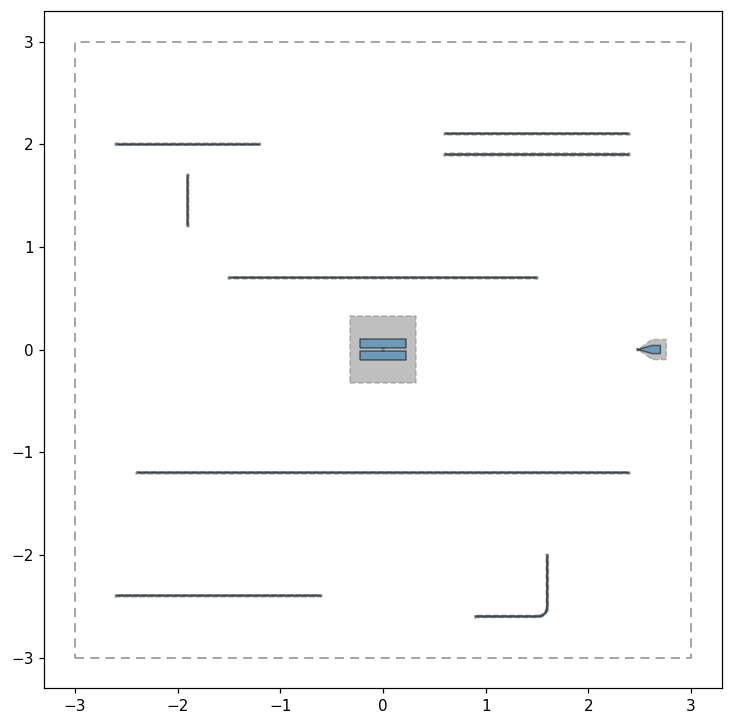

In [9]:
fig = qm.view(design)
qm.show_inline(fig)

## Tuning the rules

Thresholds are constructor arguments, so a process design kit that differs from
the defaults is a call, not a fork. Pass `rules=` to run a different set --
either a subset, or the defaults with one swapped out.

In [10]:
from qiskit_metal.validation import DEFAULT_RULES, CPWGapRule, MetalSpacingRule

# Just one rule, at a tighter limit than the default.
print(validate(design, rules=[CPWGapRule(min_gap="10um")]).report())

8 finding(s) from 1 rule(s): 0 error(s), 8 warning(s)
  [warning] cpw-gap: cross_h has a 6.00 um CPW gap (minimum 10.00 um)  @ (-1.2000, 2.0000)
  [warning] cpw-gap: cross_v has a 6.00 um CPW gap (minimum 10.00 um)  @ (-1.9000, 1.2000)
  [warning] cpw-gap: near_a has a 6.00 um CPW gap (minimum 10.00 um)  @ (2.4000, 2.1000)
  [warning] cpw-gap: near_b has a 6.00 um CPW gap (minimum 10.00 um)  @ (2.4000, 1.9000)
  [warning] cpw-gap: thin has a 6.00 um CPW gap (minimum 10.00 um)  @ (-2.6000, -2.4000)
  [warning] cpw-gap: kink has a 6.00 um CPW gap (minimum 10.00 um)  @ (1.6000, -2.6000)
  [warning] cpw-gap: hug has a 6.00 um CPW gap (minimum 10.00 um)  @ (-1.5000, 0.7000)
  [warning] cpw-gap: split has a 6.00 um CPW gap (minimum 10.00 um)  @ (-2.4000, -1.2000)


In [11]:
# The 2 um default is a fabrication limit. A crosstalk budget is a separate,
# much looser constraint -- unconnected CPWs kept 250 um apart. Replacing the
# rule rather than adding one matters: both copies would run, and the design
# would be reported twice.
house_rules = [r for r in DEFAULT_RULES if r.name != "metal-spacing"]
house_rules.append(MetalSpacingRule(min_spacing="250um"))

print(validate(design, rules=house_rules).report())

1 finding(s) from 7 rule(s): 1 error(s), 0 warning(s)
  [error] metal-spacing: near_a and near_b are 190.00 um apart (minimum 250.00 um)  @ (2.4000, 2.0000)


Severity is an argument too. Promote a warning to an error when your process
treats it as a hard rule, and the result turns falsy.

In [12]:
from qiskit_metal.validation import Severity

strict_gap = CPWGapRule(min_gap="10um", severity=Severity.ERROR)
print(bool(validate(design, rules=[strict_gap])))

False


## Failing the build

In a design script or CI job you want the check to stop the run, not print.
`strict=True` raises `DesignRuleViolation` on any error.

In [13]:
from qiskit_metal.validation import DesignRuleViolation

try:
    validate(design, rules=[strict_gap], strict=True)
except DesignRuleViolation as exc:
    print("build stopped:")
    print(str(exc).splitlines()[0])

build stopped:
8 finding(s) from 1 rule(s): 8 error(s), 0 warning(s)


The same thing, without exceptions, at the end of a build script:

```python
result = validate(design)
if not result:
    print(result.report())
    raise SystemExit(1)
```

Quantum Metal gates its own shipped reference designs this way -- see
`tests/test_reference_designs.py`.

## Writing your own rule

A rule is any object with a `name`, a `description`, and a `check(design)` that
yields `Finding`s. Subclass `DesignRule` and use the same helpers the built-in
rules use: `chip_bounds`, `component_geometry` (which unions each component's
drawn metal, per layer if you ask), and `representative_point`.

Here is a fab rule the defaults do not cover: nothing may reach into the dicing
street at the die edge.

In [14]:
from shapely.geometry import box

from qiskit_metal.validation import (
    DesignRule,
    Finding,
    chip_bounds,
    component_geometry,
    representative_point,
)


class KeepOutBorderRule(DesignRule):
    """Metal must stay clear of the dicing street at the chip edge."""

    name = "keep-out-border"
    description = "Metal reaches into the dicing street."

    def __init__(self, margin="400um", severity=Severity.ERROR):
        self.margin = margin
        self.severity = severity

    def check(self, design):
        margin = design.parse_value(self.margin)
        minx, miny, maxx, maxy = chip_bounds(design)
        keep_in = box(minx + margin, miny + margin, maxx - margin, maxy - margin)

        for name, geometry in component_geometry(design).items():
            outside = geometry.difference(keep_in)
            if outside.is_empty:
                continue
            yield Finding(
                rule=self.name,
                severity=self.severity,
                message=(
                    f"{name} reaches {margin * 1000:.0f} um into the dicing street"
                ),
                components=(name,),
                location=representative_point(outside),
                value=outside.area,
                limit=0.0,
            )


print(validate(design, rules=[KeepOutBorderRule()]).report())

2 finding(s) from 1 rule(s): 2 error(s), 0 warning(s)
  [error] keep-out-border: kink reaches 400 um into the dicing street  @ (1.2521, -2.6026)
  [error] keep-out-border: LP reaches 400 um into the dicing street  @ (2.6510, 0.0000)


## What this does not check

DRC is a geometry check. It says nothing about whether your resonator is at the
frequency you wanted, whether the coupling is right, or whether the qubit is
anharmonic enough -- those need the analysis notebooks in section 4. It also
knows nothing about your foundry's actual rule deck; the defaults are a
published starting point.

Three known limits worth stating plainly:

- **Layers are trusted.** Overlap and spacing are checked per layer, so metal on
  layer 30 crossing metal on layer 1 is fine. If your stack does not match that
  assumption, the rules will miss real shorts.
- **`net_info` is trusted.** Components joined through a pin are exempt from the
  overlap and spacing rules, because a route abutting its termination is not a
  short.
- **`ground-continuity` sees one layer.** It reports that the ground is split,
  not that a piece is floating -- an airbridge on another layer may well tie the
  pieces together.

## References

- *From GDSII to Wafer: EDA Design Flow and Data Conversion for Wafer-Scale
  Manufacturing of Superconducting Quantum Chips*,
  [arXiv:2604.11379](https://arxiv.org/abs/2604.11379) -- the R1 / R8 / R9
  thresholds used above.
- *A Review of Design Concerns in Superconducting Quantum Circuits*,
  [arXiv:2411.16967](https://arxiv.org/abs/2411.16967) -- crosstalk mechanisms
  and airbridge placement.
- Airbridges in Quantum Metal: tutorial 2.15.
- Full worked designs that pass these rules: Appendix A.